# Day 7/90 - Calculus, Gradients & Optimization for AI Engineers

> **How does a machine-learning model know how to change its parameters so that its predictions improve?**

### Parameter

A **parameter** is a value inside a model that the model **learns and changes during training**.

For a simple model:

$$
\hat{y}=wx+b
$$

- `x` → input
- `ŷ` → prediction
- `w` → **weight**, a parameter
- `b` → **bias**, a parameter

Training changes `w` and `b` so predictions improve.

### Parameter vs hyperparameter

```text
PARAMETER
→ learned by the model
→ weights, biases

HYPERPARAMETER
→ chosen/configured by us
→ learning rate, batch size, epochs
```

Today's goal is to understand **how the model knows which way to move its parameters and how large each move should be**.

## Learning path

```text
Function / Loss
→ Slope
→ Derivative
→ Partial Derivative
→ Gradient
→ Chain Rule
→ Gradient Descent
→ Learning Rate
→ Learning-Rate Decay
→ Batch / SGD / Mini-Batch
→ Convex vs Non-Convex
→ Local vs Global Minimum
```

Each concept appears once. All exercises are collected at the end.

## Setup

In [ ]:
# NumPy gives us numerical arrays and math tools.
import numpy as np

# Matplotlib lets us draw graphs.
import matplotlib.pyplot as plt

# Make printed NumPy numbers easier to read:
# precision=3 -> show about 3 decimal places
# suppress=True -> avoid scientific notation when possible
np.set_printoptions(precision=3, suppress=True)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-nef5o_l5 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Code words you will see in the graphs

You do **not** need to memorize these. They are just helper tools for drawing and calculating.

- `np.linspace(start, stop, n)` → creates `n` evenly spaced numbers between `start` and `stop`.
- `np.arange(n)` → creates whole numbers from `0` up to `n-1`.
- `np.meshgrid(x, y)` → turns x-values and y-values into a grid so we can evaluate a 2D function over many points.
- `np.diff(values)` → calculates the difference between neighboring values.
- `plt.figure(...)` → creates a new graph.
- `plt.plot(x, y)` → draws a line.
- `plt.scatter(x, y)` → draws individual points.
- `plt.axhline(...)` / `plt.axvline(...)` → draws horizontal / vertical reference lines.
- `plt.grid(True)` → shows grid lines to make the graph easier to read.
- `plt.legend()` → shows labels for plotted lines.
- `plt.show()` → displays the graph.

Whenever one of these appears below, the code comments will explain what it is doing.

# 1. Function - Input Goes In, Output Comes Out

**Definition:** A **function** is a rule that takes an input and produces an output.

Example:

$$
f(x)=x^2
$$

```text
x = 2 → f(x) = 4
x = 3 → f(x) = 9
```

In AI:

```text
model(input) → prediction
loss(prediction, correct answer) → error
```

A **loss function** measures how wrong the model is.

```text
small loss → better prediction
large loss → worse prediction
```

Training tries to make the loss smaller.

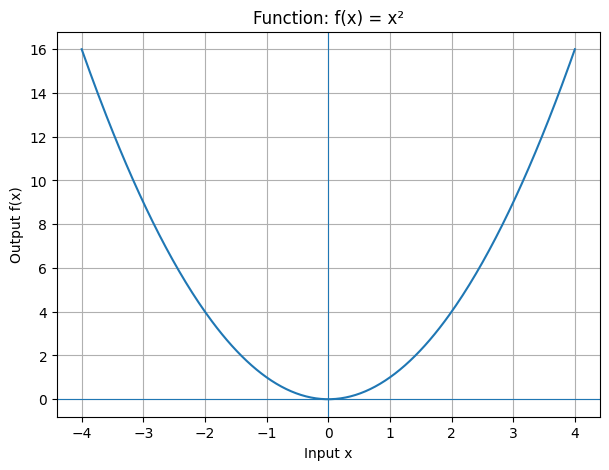

In [ ]:
# Define the function f(x) = x².
def f(x):
    return x**2

# np.linspace creates 300 evenly spaced x-values from -4 to 4.
# We use many points so the curve looks smooth.
x = np.linspace(-4, 4, 300)

# Create a new graph area.
plt.figure(figsize=(7, 5))

# Draw the curve using x-values and their outputs f(x).
plt.plot(x, f(x))

# Draw reference axes through 0.
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

# Label the axes.
plt.xlabel("Input x")
plt.ylabel("Output f(x)")

# Add a title and grid.
plt.title("Function: f(x) = x²")
plt.grid(True)

# Display the graph.
plt.show()

### What this graph shows

- **Shape:** A U-shaped curve because squaring positive or negative values gives positive outputs.
- **Each point:** One input-output pair, such as `x=2 → f(x)=4`.
- **What to notice:** As `x` moves away from `0`, the output increases.

# 2. Slope - Which Way Is the Curve Going?

**Definition:** **Slope measures how much the output changes when the input changes.**

For a line:

$$
\text{slope}=\frac{\text{change in y}}{\text{change in x}}
$$

Think:

```text
positive slope → uphill
negative slope → downhill
zero slope     → flat
```

If our goal is to reduce loss, slope helps tell us which direction is downhill.

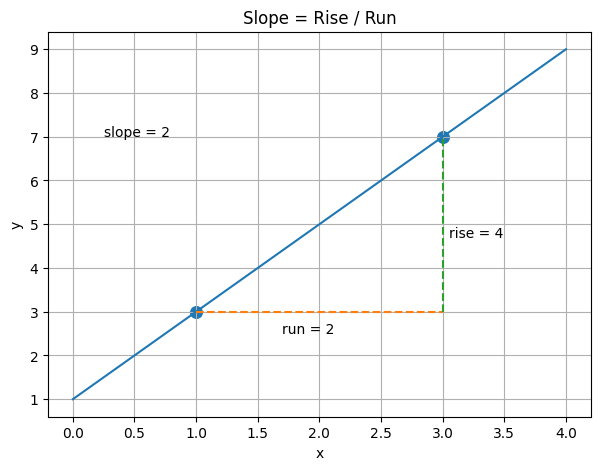

In [ ]:
# Two points on the line y = 2x + 1.
x1, y1 = 1, 3
x2, y2 = 3, 7

# Slope = change in y divided by change in x.
slope = (y2 - y1) / (x2 - x1)

# Create 100 evenly spaced x-values from 0 to 4.
x_line = np.linspace(0, 4, 100)

# Calculate y = 2x + 1 for every x-value.
y_line = 2 * x_line + 1

plt.figure(figsize=(7, 5))

# Draw the line.
plt.plot(x_line, y_line)

# Mark the two points used to calculate slope.
plt.scatter([x1, x2], [y1, y2], s=70)

# Draw dashed guides to show "run" and "rise".
plt.plot([x1, x2], [y1, y1], linestyle="--")
plt.plot([x2, x2], [y1, y2], linestyle="--")

# Add labels directly on the graph.
plt.text(1.7, 2.5, "run = 2")
plt.text(3.05, 4.7, "rise = 4")
plt.text(0.25, 7.0, f"slope = {slope:.0f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Slope = Rise / Run")
plt.grid(True)
plt.show()

### What this graph shows

- **Shape:** A straight line, so its slope is constant everywhere.
- **The two dots:** The two points used to calculate the slope.
- **Dashed horizontal part:** The **run**, or change in `x`.
- **Dashed vertical part:** The **rise**, or change in `y`.
- **What to notice:** `rise = 4`, `run = 2`, so `slope = 2`.

### Read the graph

From `(1,3)` to `(3,7)`:

```text
x changed by 2
y changed by 4
slope = 4 / 2 = 2
```

For a curved function, slope changes from point to point. That leads to derivatives.

# 3. Derivative - Slope at One Exact Point

**Definition:** A **derivative tells us the slope of a function at a particular point.**

For:

$$
f(x)=x^2
$$

$$
f'(x)=2x
$$

```text
x = -2 → slope = -4
x =  0 → slope =  0
x =  2 → slope =  4
```

A tangent line makes the local slope visible.

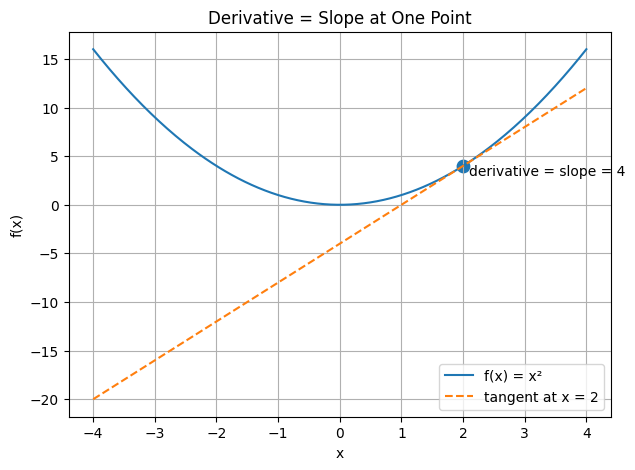

In [ ]:
# Define f(x) = x².
def f(x):
    return x**2

# Its derivative is f'(x) = 2x.
def df(x):
    return 2 * x

# Make many x-values so the curve looks smooth.
x = np.linspace(-4, 4, 300)

# We want the slope specifically at x = 2.
x0 = 2
y0 = f(x0)

# The derivative gives the slope at that point.
m = df(x0)

# Build the tangent line:
# y = y0 + slope * (x - x0)
tangent = y0 + m * (x - x0)

plt.figure(figsize=(7, 5))

# Draw the original curve.
plt.plot(x, f(x), label="f(x) = x²")

# Draw the tangent line touching the curve at x = 2.
plt.plot(x, tangent, linestyle="--", label="tangent at x = 2")

# Mark the exact point where we measure the slope.
plt.scatter([x0], [y0], s=80)

plt.text(2.1, 3.0, "derivative = slope = 4")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Derivative = Slope at One Point")
plt.legend()
plt.grid(True)
plt.show()

### What this graph shows

- **Shape:** The blue curve is `f(x)=x²`.
- **The dot:** The exact point `x=2` where we want the derivative.
- **The dashed line:** The tangent line; it shows the local direction of the curve at that point.
- **What to notice:** The tangent slope is `4`, so the derivative at `x=2` is `4`.

### Why this matters in AI

If `w` is a model parameter and `L(w)` is the loss, the derivative answers:

> **If I change `w` slightly, will the loss go up or down, and how strongly?**

# 4. Partial Derivative - One Variable at a Time

Real models have many parameters.

Suppose:

$$
f(x,y)=x^2+y^2
$$

**Definition:** A **partial derivative measures how a function changes when one variable changes while the others are kept fixed.**

```text
change x, keep y fixed → ∂f/∂x
change y, keep x fixed → ∂f/∂y
```

$$
\frac{\partial f}{\partial x}=2x
\qquad
\frac{\partial f}{\partial y}=2y
$$

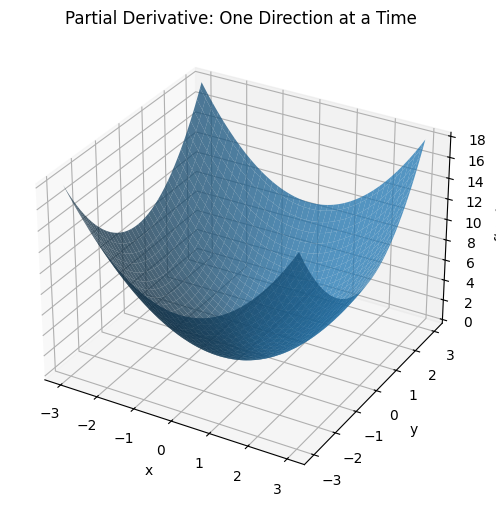

In [ ]:
# Create 80 x-values and 80 y-values from -3 to 3.
x = np.linspace(-3, 3, 80)
y = np.linspace(-3, 3, 80)

# np.meshgrid creates a full grid of x-y coordinate pairs.
# This lets us evaluate the function over a 2D surface.
X, Y = np.meshgrid(x, y)

# Compute f(x, y) = x² + y² at every grid point.
Z = X**2 + Y**2

# Create a 3D graph.
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Draw the curved surface.
ax.plot_surface(X, Y, Z, alpha=0.75)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
ax.set_title("Partial Derivative: One Direction at a Time")

plt.show()

### What this graph shows

- **Shape:** A 3D bowl representing `f(x,y)=x²+y²`.
- **x and y axes:** Two different inputs to the same function.
- **Height:** The function value `f(x,y)`.
- **What to notice:** A partial derivative asks for the slope in **one direction at a time** while the other variable is held fixed.

### Read the graph

The surface has two input directions: `x` and `y`.

A partial derivative asks for the slope in **one direction at a time**.

This matters because a model may have millions of parameters, and we need to know how the loss changes with respect to each one.

# 5. Gradient - All Partial Derivatives Together

**Definition:** The **gradient is a vector containing the partial derivative with respect to every input variable.**

For:

$$
f(x,y)=x^2+y^2
$$

$$
\nabla f(x,y)=[2x,2y]
$$

> **The gradient points in the direction of steepest increase - the fastest uphill direction.**

Therefore:

> **The negative gradient points downhill.**

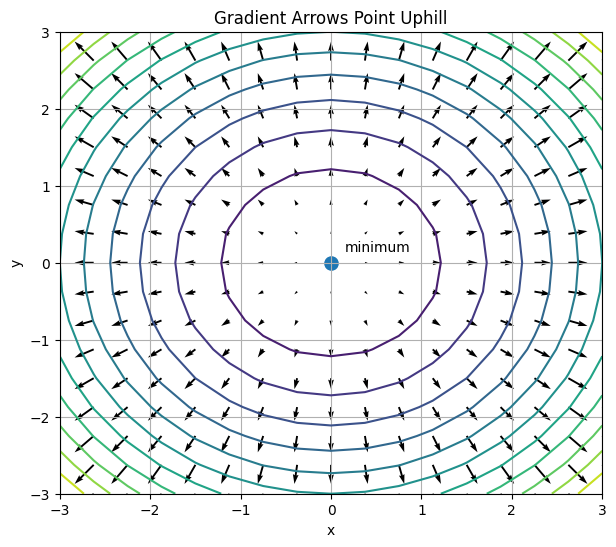

In [ ]:
# Create x and y positions for the graph.
x = np.linspace(-3, 3, 17)
y = np.linspace(-3, 3, 17)

# Build a grid of coordinates.
X, Y = np.meshgrid(x, y)

# f(x, y) = x² + y²
Z = X**2 + Y**2

# Partial derivatives:
# ∂f/∂x = 2x
# ∂f/∂y = 2y
GX = 2 * X
GY = 2 * Y

plt.figure(figsize=(7, 6))

# Contour lines show equal function values,
# like elevation lines on a map.
plt.contour(X, Y, Z, levels=12)

# quiver draws arrows.
# Each arrow points in the gradient direction.
plt.quiver(X, Y, GX, GY)

# Mark the minimum at the center.
plt.scatter([0], [0], s=90)
plt.text(0.15, 0.15, "minimum")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Arrows Point Uphill")
plt.grid(True)
plt.show()

### What this graph shows

- **Contour rings:** Points with the same function value, like elevation lines on a map.
- **Arrows:** The gradient direction at each location.
- **Center point:** The minimum.
- **What to notice:** Arrows point uphill, away from the minimum. Gradient descent therefore moves in the **opposite** direction.

### Read the graph

The center is the minimum.

The arrows point away from it because the gradient points uphill.

```text
gradient          → uphill
negative gradient → downhill
```

# 6. Chain Rule - Track an Effect Through Connected Operations

Neural networks are chains of operations.

```text
x
↓
u = 2x
↓
y = u²
```

**Definition:** The **chain rule tells us how to combine derivatives when one operation depends on another.**

$$
\frac{dy}{dx}
=
\frac{dy}{du}
\times
\frac{du}{dx}
$$

At `x = 3`:

```text
u = 6
dy/du = 12
du/dx = 2
dy/dx = 24
```

This becomes the basis of backpropagation through many layers.

In [ ]:
# Start with x = 3.
x = 3

# First operation: u = 2x.
u = 2 * x

# du/dx is the derivative of u = 2x.
du_dx = 2

# y = u², so dy/du = 2u.
dy_du = 2 * u

# Chain rule:
# dy/dx = (dy/du) * (du/dx)
dy_dx = dy_du * du_dx

print("x =", x)
print("u =", u)
print("dy/du =", dy_du)
print("du/dx =", du_dx)
print("dy/dx =", dy_dx)

x = 3
u = 6
dy/du = 12
du/dx = 2
dy/dx = 24


# 7. Gradient Descent - Walk Downhill to Reduce Loss

Suppose one parameter `w` has this loss:

$$
L(w)=(w-3)^2
$$

Start at `w = -4`.

**Definition:** **Gradient descent repeatedly updates parameters in the opposite direction of the gradient to reduce the loss.**

$$
w_{new}=w_{old}-\alpha\times\text{gradient}
$$

`α` is the learning rate.

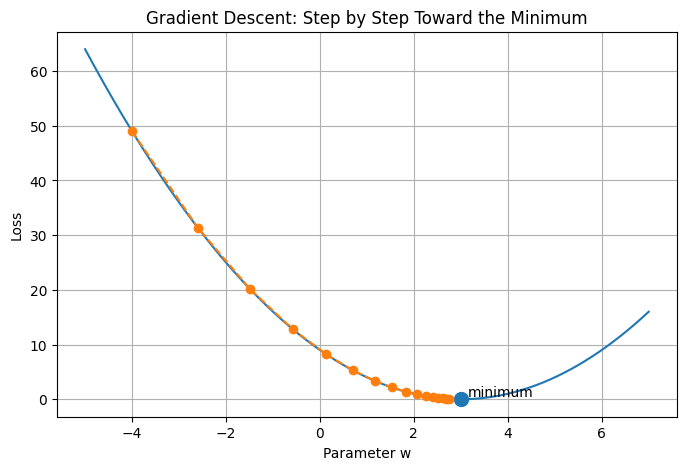

In [ ]:
# Loss function:
# The lowest possible loss happens at w = 3.
def loss(w):
    return (w - 3)**2

# Derivative of the loss.
# This tells us the slope at the current value of w.
def loss_gradient(w):
    return 2 * (w - 3)

# Start far away from the minimum.
w = -4.0

# Learning rate controls the step size.
learning_rate = 0.1

# Keep every visited value so we can draw the path later.
history = [w]

# Take 15 gradient-descent steps.
for _ in range(15):
    # Find the current gradient.
    grad = loss_gradient(w)

    # Move in the OPPOSITE direction of the gradient.
    w = w - learning_rate * grad

    # Save the new parameter value.
    history.append(w)

# Convert the Python list to a NumPy array
# so we can apply the loss function to all saved values.
history = np.array(history)

# Create many w-values to draw the full loss curve.
w_curve = np.linspace(-5, 7, 400)

plt.figure(figsize=(8, 5))

# Draw the loss curve.
plt.plot(w_curve, loss(w_curve))

# Draw the sequence of parameter updates.
plt.plot(history, loss(history), marker="o", linestyle="--")

# Mark the minimum.
plt.scatter([3], [0], s=100)
plt.text(3.15, 0.5, "minimum")

plt.xlabel("Parameter w")
plt.ylabel("Loss")
plt.title("Gradient Descent: Step by Step Toward the Minimum")
plt.grid(True)
plt.show()

### What this graph shows

- **U-shaped curve:** The loss function.
- **Each dot:** One value of the model parameter `w`.
- **Dashed path:** The sequence of updates made by gradient descent.
- **Lowest point:** The minimum loss at `w=3`.
- **What to notice:** Each update moves the parameter closer to the minimum and reduces the loss.

### Read the graph

Each dot is one update.

```text
start
↓
take a downhill step
↓
loss gets smaller
↓
repeat
```

# 8. Learning Rate - How Big Should Each Step Be?

**Definition:** The **learning rate is a hyperparameter that controls the size of each parameter update during gradient descent.**

```text
too small → tiny steps → safe but slow

good size → steady steps → efficient

too large → huge jumps → overshoots / oscillates / may diverge
```

The next three graphs match the intuition in your notes.

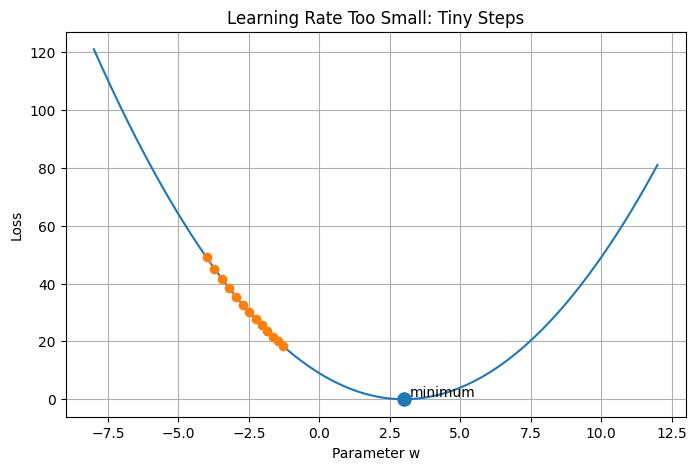

In [ ]:
# Helper function:
# Run gradient descent and return every visited parameter value.
def run_gd(start, lr, steps=12):
    w = start
    hist = [w]

    for _ in range(steps):
        # Move downhill using the chosen learning rate.
        w = w - lr * loss_gradient(w)
        hist.append(w)

    return np.array(hist)

# Create many x-values to draw a smooth loss curve.
curve_x = np.linspace(-8, 12, 700)

# Use a very small learning rate.
small = run_gd(-4, 0.02, 12)

plt.figure(figsize=(8, 5))
plt.plot(curve_x, loss(curve_x))

# Each dot is one parameter update.
plt.plot(small, loss(small), marker="o", linestyle="--")

# Mark the minimum.
plt.scatter([3], [0], s=90)
plt.text(3.2, 1.0, "minimum")

plt.xlabel("Parameter w")
plt.ylabel("Loss")
plt.title("Learning Rate Too Small: Tiny Steps")
plt.grid(True)
plt.show()

### What this graph shows

- **Curve:** The loss landscape.
- **Dots:** Parameter updates.
- **What to notice:** The dots move in the correct direction but are very close together. The learning rate is so small that progress is slow.

### Too small

```text
small learning rate
→ tiny parameter updates
→ correct direction
→ slow training
```

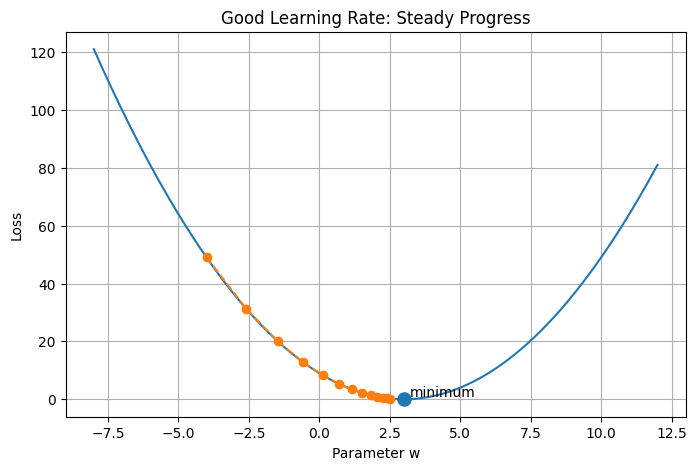

In [ ]:
# Run gradient descent with a more useful learning rate.
good = run_gd(-4, 0.10, 12)

plt.figure(figsize=(8, 5))
plt.plot(curve_x, loss(curve_x))

# The dots move toward the minimum more efficiently.
plt.plot(good, loss(good), marker="o", linestyle="--")

plt.scatter([3], [0], s=90)
plt.text(3.2, 1.0, "minimum")

plt.xlabel("Parameter w")
plt.ylabel("Loss")
plt.title("Good Learning Rate: Steady Progress")
plt.grid(True)
plt.show()

### What this graph shows

- **Curve:** The same loss landscape.
- **Dots:** Parameter updates.
- **What to notice:** The steps are larger and move steadily toward the minimum without becoming unstable.

### Reasonable

```text
reasonable learning rate
→ useful step size
→ fast enough
→ stable movement
```

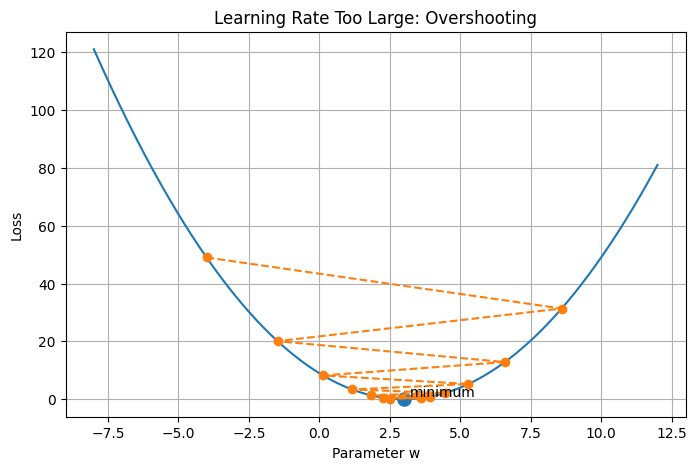

In [ ]:
# Run gradient descent with a large learning rate.
large = run_gd(-4, 0.90, 12)

# Expand the graph range in case the updates jump far away.
xmin = min(-8, large.min() - 1)
xmax = max(12, large.max() + 1)

# Create many x-values across that larger range.
large_x = np.linspace(xmin, xmax, 900)

plt.figure(figsize=(8, 5))
plt.plot(large_x, loss(large_x))

# The dots may jump from one side of the minimum to the other.
plt.plot(large, loss(large), marker="o", linestyle="--")

plt.scatter([3], [0], s=90)
plt.text(3.2, 1.0, "minimum")

plt.xlabel("Parameter w")
plt.ylabel("Loss")
plt.title("Learning Rate Too Large: Overshooting")
plt.grid(True)
plt.show()

### What this graph shows

- **Curve:** The loss landscape.
- **Dots:** Parameter updates.
- **What to notice:** The updates jump across the minimum instead of settling smoothly. This is **overshooting**.

### Too large

```text
large learning rate
→ jumps across the minimum
→ oscillates
→ may diverge
```

# 9. Learning-Rate Decay - Large Steps First, Smaller Steps Later

**Definition:** **Learning-rate decay means gradually reducing the learning rate as training progresses.**

```text
far from minimum → larger steps
near minimum     → smaller, careful steps
```

A rule that changes learning rate over time is called a **learning-rate schedule**.

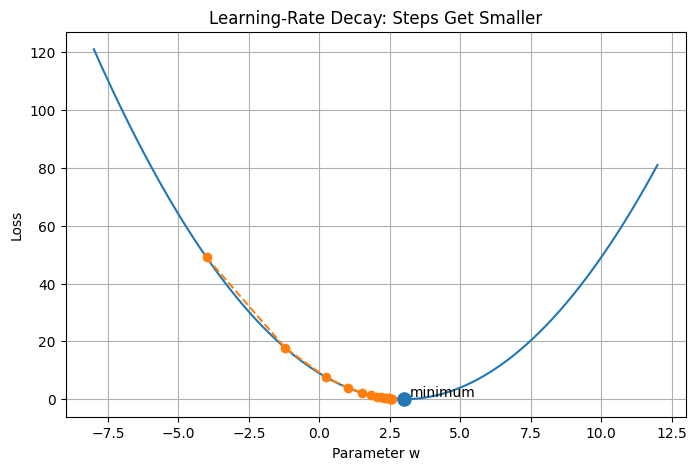

In [ ]:
# Gradient descent where the learning rate shrinks over time.
def gd_with_decay(start, initial_lr=0.20, decay=0.85, steps=15):
    w = start
    hist = [w]
    lrs = []

    for step in range(steps):
        # learning rate = initial rate × decay^step
        # So each later step uses a smaller learning rate.
        lr = initial_lr * (decay**step)

        # Save the learning rate so we can graph it later.
        lrs.append(lr)

        # Update the parameter using the current learning rate.
        w = w - lr * loss_gradient(w)

        # Save the new parameter value.
        hist.append(w)

    return np.array(hist), np.array(lrs)

# Run the decaying-learning-rate version.
decay_history, decay_lrs = gd_with_decay(-4)

plt.figure(figsize=(8, 5))
plt.plot(curve_x, loss(curve_x))
plt.plot(
    decay_history,
    loss(decay_history),
    marker="o",
    linestyle="--"
)

plt.scatter([3], [0], s=90)
plt.text(3.2, 1.0, "minimum")

plt.xlabel("Parameter w")
plt.ylabel("Loss")
plt.title("Learning-Rate Decay: Steps Get Smaller")
plt.grid(True)
plt.show()

### What this graph shows

- **Early dots:** Larger steps while the parameter is far from the minimum.
- **Later dots:** Smaller steps near the minimum.
- **What to notice:** Learning-rate decay lets optimization move quickly first and more carefully later.

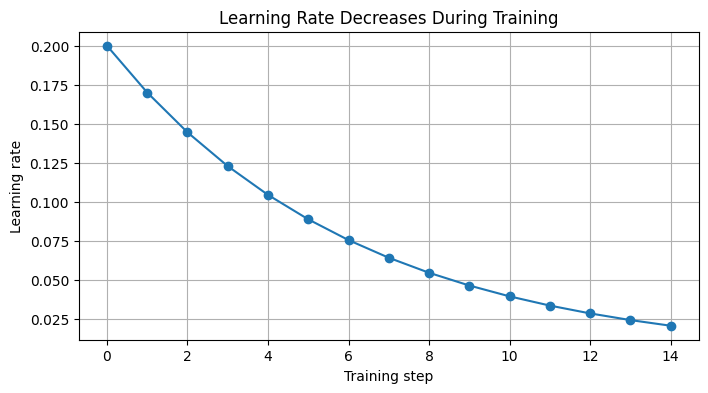

In [ ]:
# np.arange(len(decay_lrs)) creates step numbers:
# 0, 1, 2, 3, ...
steps = np.arange(len(decay_lrs))

plt.figure(figsize=(8, 4))

# Plot training step on the x-axis
# and learning rate on the y-axis.
plt.plot(steps, decay_lrs, marker="o")

plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.title("Learning Rate Decreases During Training")
plt.grid(True)
plt.show()

### What this graph shows

- **x-axis:** Training step.
- **y-axis:** Current learning rate.
- **Each point:** The learning rate used at that step.
- **What to notice:** The learning rate gradually decreases over time.

# 10. Batch, SGD & Mini-Batch Gradient Descent

> **How much training data do we use to calculate one gradient before updating the parameters?**

Suppose we have 1,000 training examples.

### Batch Gradient Descent

```text
all 1000 examples
↓
one gradient
↓
one update
```

### Stochastic Gradient Descent (SGD)

```text
1 example → gradient → update
1 example → gradient → update
...
```

### Mini-Batch Gradient Descent

```text
32 examples → gradient → update
next 32    → gradient → update
...
```

**Mini-batches are very common in deep learning.**

### Important terms

**Training example:** one item in the training dataset.

**Batch:** examples used for one gradient calculation.

**Batch size:** number of examples in one batch.

**Epoch:** one complete pass through the entire training dataset.

`batch_size` is a **hyperparameter**.

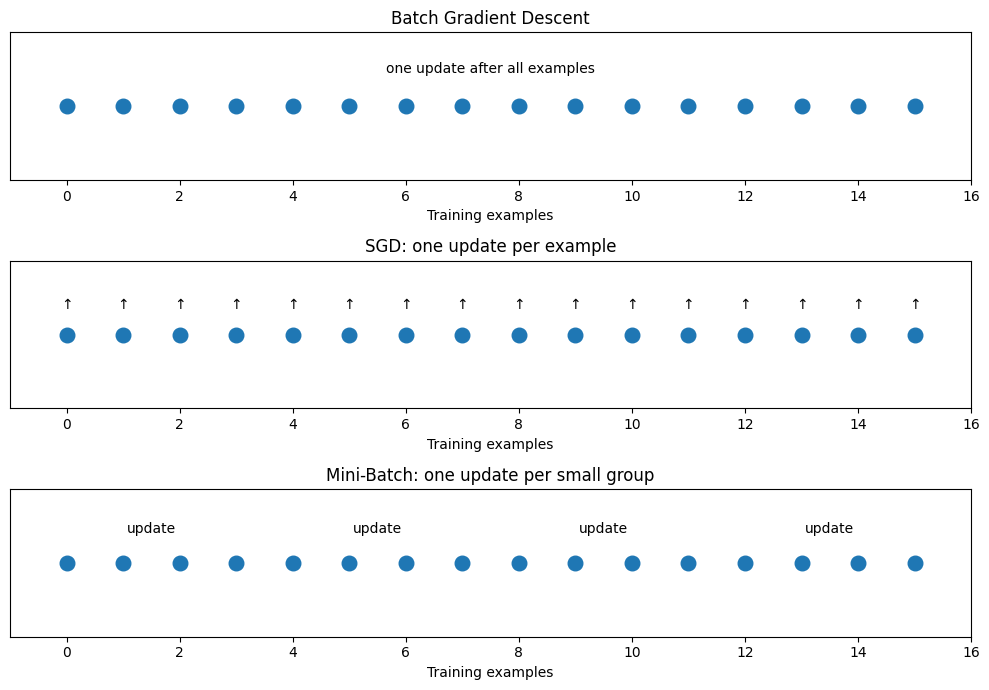

In [ ]:
# Use only 16 examples so the diagram is easy to see.
n = 16

# Each mini-batch will contain 4 examples.
batch_size = 4

# Create 3 separate graph rows:
# 1) Batch gradient descent
# 2) SGD
# 3) Mini-batch gradient descent
fig, axes = plt.subplots(3, 1, figsize=(10, 7))

# -------------------------
# Batch Gradient Descent
# -------------------------
# Draw all 16 examples.
axes[0].scatter(np.arange(n), np.ones(n), s=110)

# Show that the update happens after using all examples.
axes[0].text(
    7.5, 1.09,
    "one update after all examples",
    ha="center"
)
axes[0].set_title("Batch Gradient Descent")
axes[0].set_yticks([])

# -------------------------
# SGD
# -------------------------
axes[1].scatter(np.arange(n), np.ones(n), s=110)

# Put an arrow above every example:
# one example -> one update.
for i in range(n):
    axes[1].text(i, 1.07, "↑", ha="center")

axes[1].set_title("SGD: one update per example")
axes[1].set_yticks([])

# -------------------------
# Mini-Batch Gradient Descent
# -------------------------
axes[2].scatter(np.arange(n), np.ones(n), s=110)

# Group examples into batches of 4.
for start in range(0, n, batch_size):
    end = min(start + batch_size - 1, n - 1)
    center = (start + end) / 2

    # Put "update" above the center of each group.
    axes[2].text(center, 1.08, "update", ha="center")

axes[2].set_title("Mini-Batch: one update per small group")
axes[2].set_yticks([])

# Give all three graphs the same layout.
for ax in axes:
    ax.set_xlim(-1, n)
    ax.set_ylim(0.8, 1.2)
    ax.set_xlabel("Training examples")

plt.tight_layout()
plt.show()

### What this diagram shows

- **Each dot:** One training example.
- **Batch row:** All examples are used before one update.
- **SGD row:** Every example causes an update.
- **Mini-batch row:** Small groups of examples cause updates.
- **What to notice:** The difference is **how much data is used before each parameter update**.

### Practical intuition

```text
Batch      → stable but expensive
SGD        → frequent but noisy
Mini-batch → practical balance; common in neural-network training
```

# 11. Convex vs Non-Convex Objectives

An **objective function** is the function we are trying to optimize. During training, this is usually the loss.

### Convex

**Definition:** A **convex objective is bowl-shaped so any local minimum is also a global minimum.**

Example:

$$
f(x)=x^2
$$

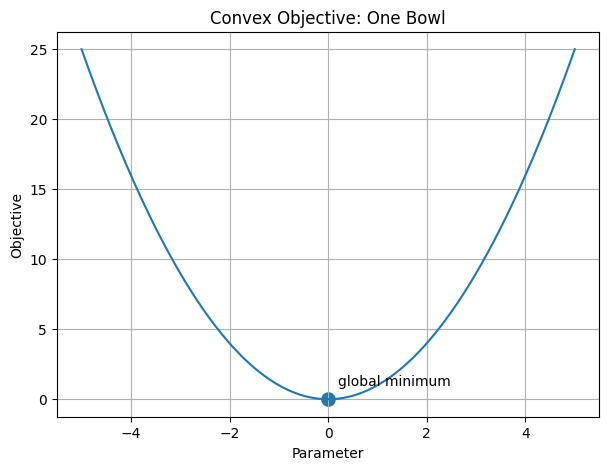

In [ ]:
# Create x-values from -5 to 5.
x = np.linspace(-5, 5, 400)

plt.figure(figsize=(7, 5))

# Draw f(x) = x².
# This creates a bowl-shaped convex curve.
plt.plot(x, x**2)

# Mark the lowest point.
plt.scatter([0], [0], s=90)
plt.text(0.2, 1.0, "global minimum")

plt.xlabel("Parameter")
plt.ylabel("Objective")
plt.title("Convex Objective: One Bowl")
plt.grid(True)
plt.show()

### What this graph shows

- **Shape:** One smooth bowl.
- **Bottom point:** The global minimum.
- **What to notice:** There is one clear lowest region, which makes optimization easier to reason about.

### Non-convex

**Definition:** A **non-convex objective can contain multiple valleys, peaks, flat regions, and different minima.**

Neural-network loss surfaces are generally non-convex.

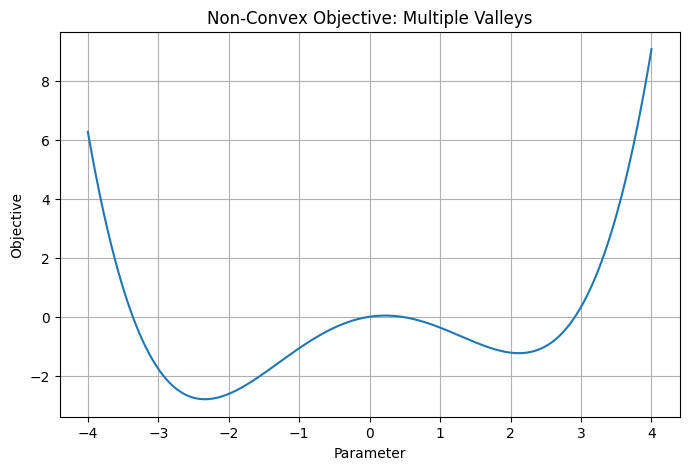

In [ ]:
# Create many x-values so the curve looks smooth.
x = np.linspace(-4, 4, 1000)

# This polynomial creates multiple valleys.
y = 0.08*x**4 - 0.8*x**2 + 0.35*x

plt.figure(figsize=(8, 5))
plt.plot(x, y)

plt.xlabel("Parameter")
plt.ylabel("Objective")
plt.title("Non-Convex Objective: Multiple Valleys")
plt.grid(True)
plt.show()

### What this graph shows

- **Shape:** Multiple hills and valleys.
- **What to notice:** There can be several low regions, so optimization is more complicated than on a simple bowl.

# 12. Local vs Global Minimum

**Local minimum:** lower than the nearby points around it.

**Global minimum:** the lowest point anywhere in the entire function.

```text
local minimum  → small valley
global minimum → deepest valley overall
```

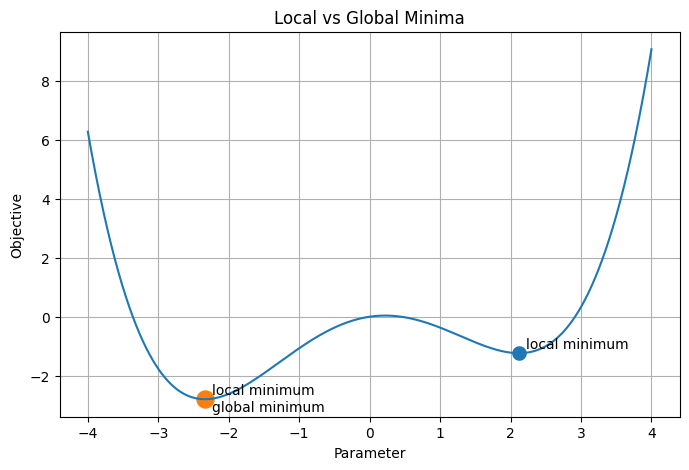

In [ ]:
# Create many x-values so we can inspect the whole curve.
x = np.linspace(-4, 4, 3000)

# Non-convex objective with more than one valley.
y = 0.08*x**4 - 0.8*x**2 + 0.35*x

# np.diff(y) calculates how y changes between neighboring points.
dy = np.diff(y)

# A local minimum happens where the curve changes
# from decreasing (negative difference) to increasing (positive difference).
mins = np.where(
    (dy[:-1] < 0) & (dy[1:] > 0)
)[0] + 1

# Get the x and y values of those local minima.
min_x = x[mins]
min_y = y[mins]

# np.argmin(y) returns the index of the smallest y-value.
# That point is the global minimum.
global_idx = np.argmin(y)

plt.figure(figsize=(8, 5))
plt.plot(x, y)

# Mark all detected local minima.
plt.scatter(min_x, min_y, s=90)

for px, py in zip(min_x, min_y):
    plt.text(px + 0.1, py + 0.15, "local minimum")

# Mark the deepest point more strongly.
plt.scatter(
    [x[global_idx]],
    [y[global_idx]],
    s=150
)

plt.text(
    x[global_idx] + 0.1,
    y[global_idx] - 0.4,
    "global minimum"
)

plt.xlabel("Parameter")
plt.ylabel("Objective")
plt.title("Local vs Global Minima")
plt.grid(True)
plt.show()

### What this graph shows

- **Local minimum:** A valley that is lower than nearby points.
- **Global minimum:** The deepest valley in the entire graph.
- **What to notice:** A point can be locally low without being the best possible solution overall.

### Key intuition

Gradient descent only knows the slope **where it currently is**. It does not see the whole landscape at once.

> **Local = lowest nearby. Global = lowest overall.**

# 13. Put Everything Together - How Model Training Works

```text
1. Take a batch of training data
        ↓
2. Model uses its parameters
        ↓
3. Make predictions
        ↓
4. Loss measures the error
        ↓
5. Derivatives / gradients measure how parameters affect loss
        ↓
6. Chain rule carries those effects through the model
        ↓
7. Gradient descent chooses the downhill direction
        ↓
8. Learning rate controls step size
        ↓
9. Update parameters
        ↓
10. Repeat
```

After the model has seen the entire training dataset once:

> **One epoch is complete.**

# 14. Practice Assignment

All exercises are here so the learning guide above stays clean.

## Exercise 1 - Function

Create and plot:

$$
f(x)=3x+2
$$

Calculate `f(0)`, `f(2)`, and `f(5)`.

In [ ]:
# Write your code here

## Exercise 2 - Slope

Find the slope between:

```text
A = (1, 4)
B = (4, 13)
```

Calculate manually first.

In [ ]:
# Write your code here

## Exercise 3 - Derivative

For:

$$
f(x)=x^3
$$

$$
f'(x)=3x^2
$$

Find the derivative at `x = 3`.

In [ ]:
# Write your code here

## Exercise 4 - Partial Derivative & Gradient

For:

$$
f(x,y)=x^2+4y^2
$$

at `x=2, y=1`, find both partial derivatives and the gradient.

In [ ]:
# Write your code here

## Exercise 5 - Chain Rule

Let:

```text
u = 3x
y = u²
```

Find `dy/dx` at `x = 2`.

In [ ]:
# Write your code here

## Exercise 6 - Gradient Descent

Use:

$$
L(w)=(w-5)^2
$$

Start with:

```text
w = -3
learning rate = 0.1
```

Run 20 updates and plot the path.

In [ ]:
# Write your code here

## Exercise 7 - Learning Rate

Run the same optimization with:

```text
0.01
0.10
0.90
1.10
```

Decide which is slow, stable, oscillating, or diverging.

In [ ]:
# Write your code here

## Exercise 8 - Learning-Rate Decay

Use:

```text
initial learning rate = 0.2
decay = 0.8
```

Calculate and plot the first 8 learning rates.

In [ ]:
# Write your code here

## Exercise 9 - Batch Size

Suppose:

```text
training examples = 10,000
batch size = 64
```

Answer:

1. Approximately how many mini-batches are in one epoch?
2. Approximately how many parameter updates happen in one epoch?
3. Is `batch_size` a parameter or hyperparameter?

In [ ]:
# Write your code here

## Exercise 10 - Convex vs Non-Convex

Plot:

```text
f(x) = x²
g(x) = 0.1x⁴ - x²
```

Which is convex? Which has multiple low regions?

In [ ]:
# Write your code here

## Final Challenge

Explain this without looking back:

```text
batch
↓
prediction
↓
loss
↓
gradient
↓
learning rate
↓
parameter update
↓
repeat
```

If you can explain **why the model moves opposite the gradient** and **what learning rate controls**, you understand the core of Day 7.

**Practice, don't just read. Happy learning!**